<a href="https://colab.research.google.com/github/lee-doris/HealthCareAnalysis/blob/main/20260808.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

# Replace with your copied Raw GitHub URL
url = "https://raw.githubusercontent.com/lee-doris/HealthCareAnalysis/refs/heads/main/enhanced_health_insurance_claims.csv"

# Load the dataset into a pandas DataFrame
df = pd.read_csv(url)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ClaimID                  4500 non-null   object 
 1   PatientID                4500 non-null   object 
 2   ProviderID               4500 non-null   object 
 3   ClaimAmount              4500 non-null   float64
 4   ClaimDate                4500 non-null   object 
 5   DiagnosisCode            4500 non-null   object 
 6   ProcedureCode            4500 non-null   object 
 7   PatientAge               4500 non-null   int64  
 8   PatientGender            4500 non-null   object 
 9   ProviderSpecialty        4500 non-null   object 
 10  ClaimStatus              4500 non-null   object 
 11  PatientIncome            4500 non-null   float64
 12  PatientMaritalStatus     4500 non-null   object 
 13  PatientEmploymentStatus  4500 non-null   object 
 14  ProviderLocation        

In [5]:
# 1. 將收入切分為 3 個等分區間 (Low, Medium, High) (人數除以三)
df['IncomeGroup'] = pd.qcut(df['PatientIncome'], q=3, labels=['Low', 'Medium', 'High'])

# 這裡的分法機制如下：

# 1. 分割核心邏輯：等數量切分（Equal-sized Buckets）
# q=3：代表要將資料切分成 3 個等分（三位分點 / Tertiles）。
# 分法依據：Pandas 會先把所有病患的 PatientIncome 從小到大進行排序，然後依照資料筆數均分成 3 等分。
# 各組筆數：因為你的資料總共有 4,500 筆（從你的 df.info() 可以看到），所以每組會剛好分到 1,500 筆：
# Low（低收入組）：收入最低的前 33.3%（第 1 ~ 1,500 筆）
# Medium（中收入組）：中間的 33.3%（第 1,501 ~ 3,000 筆）
# High（高收入組）：收入最高的後 33.3%（第 3,001 ~ 4,500 筆）

# # 不帶 labels，讓 Pandas 印出實際的數字區間範圍
# pd.qcut(df['PatientIncome'], q=3).value_counts().sort_index()


# 2. 比較不同收入群體的平均理賠金額與拒賠率
# income_analysis = df.groupby('IncomeGroup').agg(
#     Avg_Claim=('ClaimAmount', 'mean'),
#     Total_Claims=('ClaimAmount', 'count')
# ).reset_index()

# 加上 observed=False 即可消除警告訊息
income_analysis = df.groupby('IncomeGroup', observed=False).agg(
    Avg_Claim=('ClaimAmount', 'mean'),
    Total_Claims=('ClaimAmount', 'count')
).reset_index()

# 3. 結合收入群體與理賠狀態的交叉表
income_status = pd.crosstab(df['IncomeGroup'], df['ClaimStatus'], normalize='index') * 100
print(income_analysis)
print("\n=== 各收入群體理賠狀態比例 (%) ===")
print(income_status.round(2))

  IncomeGroup    Avg_Claim  Total_Claims
0         Low  4949.971767          1500
1      Medium  5005.941820          1500
2        High  5086.698013          1500

=== 各收入群體理賠狀態比例 (%) ===
ClaimStatus  Approved  Denied  Pending
IncomeGroup                           
Low             33.00   34.67    32.33
Medium          34.40   33.67    31.93
High            34.07   32.47    33.47


In [6]:
# 分析不同申請管道 (Submission Method) 的核准/拒賠/待審核比例
submission_analysis = pd.crosstab(df['ClaimSubmissionMethod'], df['ClaimStatus'], normalize='index') * 100
print("=== 申請管道與理賠狀態交叉表 (%) ===")
print(submission_analysis.round(2))

=== 申請管道與理賠狀態交叉表 (%) ===
ClaimStatus            Approved  Denied  Pending
ClaimSubmissionMethod                           
Online                    32.85   35.93    31.21
Paper                     33.94   33.10    32.97
Phone                     34.65   31.84    33.51


In [8]:
# 1. 將 ClaimDate 轉為 datetime 格式
df['ClaimDate'] = pd.to_datetime(df['ClaimDate'])


# 將原本被當成「一般文字（string / object）」的日期欄位，轉換成 Pandas 專屬的時間型態（datetime64）

# 1. 提取時間細節（使用 .dt 屬性）

# Python
# df['Year'] = df['ClaimDate'].dt.year        # 抓出年份 (例如 2026)
# df['Month'] = df['ClaimDate'].dt.month      # 抓出月份 (1~12)
# df['DayOfWeek'] = df['ClaimDate'].dt.day_name() # 抓出星期幾 (例如 Monday)

# 2. 進行時間分組與趨勢分析（resample）
# 你可以像前面練習過的一樣，直接按「月（ME）」或「季（QE）」統計理賠總金額：

# Python
# # 依月份統計理賠趨勢
# monthly_trend = df.resample('ME', on='ClaimDate')['ClaimAmount'].sum()
# 3. 計算時間間隔（日期加減）
# 如果資料裡有另一個日期欄位（如住院日期與出院日期），你可以直接做減法：

# Python
# # 計算理賠處理天數
# df['ProcessingDays'] = df['ApprovalDate'] - df['ClaimDate']





# 2. 按月份 (Month) 統計理賠總金額與總件數
monthly_trend = df.resample('ME', on='ClaimDate').agg(
    Total_Amount=('ClaimAmount', 'sum'),
    Claim_Count=('ClaimAmount', 'count')
).reset_index()

# 代碼	代表意義	範例用途
# 'D'	Daily（每日）	觀察每天的理賠量波動
# 'W'	Weekly（每周）	按周統計理賠金額
# 'ME'	Month End（月底）	觀察每月趨勢（取代舊版的 'M'）
# 'QE'	Quarter End（季末）	製作每季財務報表
# 'YE'	Year End（年末）	觀察年度成長率



# 格式化日期顯示為 YYYY-MM
monthly_trend['YearMonth'] = monthly_trend['ClaimDate'].dt.strftime('%Y-%m')
print("=== 每月理賠趨勢 ===")
print(monthly_trend[['YearMonth', 'Total_Amount', 'Claim_Count']].head())

=== 每月理賠趨勢 ===
  YearMonth  Total_Amount  Claim_Count
0   2022-07     627192.02          135
1   2022-08     912731.32          192
2   2022-09     877252.34          176
3   2022-10    1027010.54          197
4   2022-11     988598.28          192


/tmp/ipykernel_477/2675660019.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


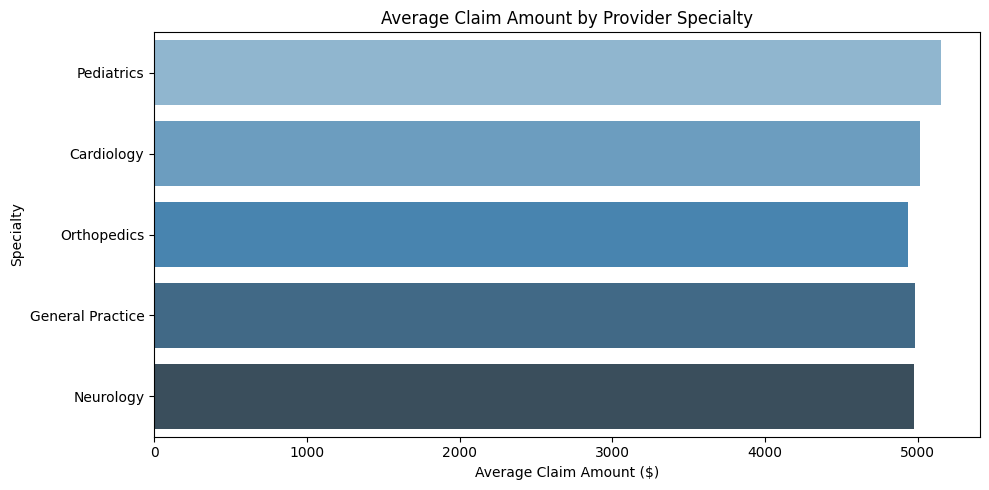

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 重新計算 cost_ranking 確保變數存在
cost_ranking = df.groupby('ProviderSpecialty')['ClaimAmount'].agg(
    Total_Claim_Amount='sum',
    Average_Claim_Amount='mean',
    Claim_Count='count'
).reset_index().sort_values(by='Total_Claim_Amount', ascending=False)

# 2. 繪製圖表
plt.figure(figsize=(10, 5))
sns.barplot(
    data=cost_ranking,
    x='Average_Claim_Amount',
    y='ProviderSpecialty',
    palette='Blues_d'
)

plt.title('Average Claim Amount by Provider Specialty')
plt.xlabel('Average Claim Amount ($)')
plt.ylabel('Specialty')
plt.tight_layout()
plt.show()